# Redundancy Detection with Dleto Chiseling

`CC-BY 2025 Brooksbank, Kassabov, Wilson`

This tutorial uses Dleto's "Tucker Chisels" to reproduce a Tucker Decompositions, also known as radical/total zero-divisor detection.

> A **Tucker Decomposition** of a tensor $\Gamma$ framed by axes (a.k.a. modes/legs/indices) $\mathbb{K}^{d_1},\ldots, \mathbb{K}^{d_{\ell}}$, is a subset of axes $A\subset\{1,\ldots,\ell\}$ and a decomposition
> $$\forall a\in A,\qquad \mathbb{K}^{d_a}=E_a\oplus R_a$$
> such that $\Gamma$ contracted on $R_a$ is 0.  

The decompositions can be given by a partitioned bases of $E_a$ and $R_a$, or equivalently by a linear projections $e_a:\mathbb{K}^{d_a}\to \mathbb{K}^{e_a}$ with kernel $R_a$.  In many situations the purpose of a Tucker decomposition is to restrict the tensor the $E_a$-spaces.  In that case it is sufficient to return only $E_a$ (respectively $e_a$) and to refer to that restriction as the Tucker Decomposition.  `Dleto` offers both forms of Tucker decomposition as an option.

 1. [Loading Dleto](#1-loading-dleto)
 2. [Creating a Tensor Experiment](#2-creating-tensor-experiment)
 3. [Tucker chiseling](#3-tucker-chiseling)
 4. Derivation selection.
___

**Performance Remark.** Tucker decompositions have been explored since the 1800's and as such there are many optimized strategies to discover them.  This tutorial therefore should be seen as using a familiar problem to explore the range of options of Dleto chisels and the use of the parameters available to Dleto chiseling.  Unfortunately, Dleto chiselling operates with a complexity slightly greater than many more direct strategies for Tucker decompositions.  For high-performance computations, Dleto automatically switches to alternative optimized strategies by calling `nondeg`. 


## 1. Loading Dleto

Start by loading `Dleto.jl`.  If this is your first time you may need to install auxiliary packages and possibly set up Julia for notebooks.  That is a one-time setup for most users, see instructions here or consider using the fully online Binder demonstration.

In [ ]:
# Uncomment and run the first time, if Dleto is not installed
# using Pkg

# Option 1: To install from remote repository, use:
# Pkg.add(url="https://github.com/thetensor-space/OpenDleto")

# Option 2: If cloned locally at PATH 
# Pkg.activate( PATH ) 

If you have already added Dleto to your Julia packages begin by loading the necessary packages, `ITensors` for general tensor controls, `Plots` for visualization tools, and `Dleto` the primary package of chisel techniques.

In [1]:
using ITensors
using Plots
using Dleto

## 2 Creating Tensor Experiment

Our first experiment is the simplest demonstration of chiseling uncovering some form of structure.  

We create two tensors, one randomized for control, and an identical in size but with 2 rows, columns, and slices set to all zero.  We then randomize the experiment tensor by applying a change in coordinates.  The goal is to using chiseling to detect and recover the hidden zero rows/columns/slices.

We note that this experiment is extremely basic and there are faster algorithms to recover this structure known under the names of **detecting radicals** or **Tucker decompositions**.  `Delto.jl` makes use of those faster methods for large scale experiments, but this experiment simply uses generic Delto methods to explore what is possible.


> **Note** Julia being mathematically oriented accepts $\LaTeX$ styled commands with tab-completion.  For example to insert the Unicode character for $\Gamma$ use `\Gamma` in the code area followed by `tab` (or cut-and-paste a character you see somewhere else).  Or replace with an simpler string of characters of your liking.  One suggestion, `Dleto.jl` calculations make substantial use of tensors, matrices, and lists of matrices.  A convention that clearly indicates those roles will be an investment worth your time.  
>
> We will be using:
> * capitol Greek letters `Γ` (`\Gamma`), `Δ` (`\Delta`), `Σ` (`\Sigma`), `Ξ` (`\Xi`), `Υ` (`\Upsilon`), etc. for tensors
> * capital English letters `X`, `Y`, `Z` etc. for matrices
> * lower case Geek letters for real numbers
> * lower case English letters for integers
> * Plural for lists of data, for instance `Γs` and `Xs`.

In [2]:
ds = (5,5,5); rs=(3,3,3)
Γ = randn(Float64, ds);  # a control tensor

# the experiment tensor is initially 0 but we fill in a subregion.
Δ = zeros(Float64, ds);  
Δ[1:rs[1], 1:rs[2], 1:rs[3]] .= randn(rs...)

side_by_side(Γ, Δ; left_title="Control Γ", right_title="Experiment Δ")

Control Γ 
 5×5×5 Array{Float64, 3}:
[:, :, 1] =
 0.312761 -0.5183 0.581289 -0.472392 0.0726624
 -0.164138 0.375232 -1.00559 -0.439533 2.05621
 -0.121438 1.75442 -0.223134 -0.942726 0.0691393
 0.4105 0.549516 -0.904957 -1.08525 0.959978
 0.0752888 -0.295956 0.270873 0.621465 -0.175525

[:, :, 2] =
 -1.42624 1.16882 2.92949 -0.827391 -0.829916
 -0.0752668 1.1813 0.716276 0.487219 0.621471
 -0.0610363 0.296345 0.451656 -0.252985 -1.35422
 0.799122 1.22678 0.674977 0.388326 -2.24575
 0.798031 0.692075 0.608272 -1.07114 -0.27324

[:, :, 3] =
 0.443528 0.270715 -0.12562 1.50934 -1.4504
 0.317038 0.0810753 0.171855 0.866008 1.19085
 0.932103 0.243006 -0.247889 0.657842 -0.911216
 -0.80682 -0.234377 0.574663 -0.224639 0.146435
 -1.63282 -1.47273 0.603134 0.438366 1.10361

[:, :, 4] =
 0.480075 -0.934864 -0.905738 0.158937 -1.21276
 -0.237348 1.60375 0.117931 -0.50872 -0.544598
 0.358514 1.51934 1.2393 0.768801 -0.277156
 -0.618178 -0.809826 1.38989 -0.224863 1.23361
 -0.26602 0.112278 -0.264895 -0.686516 -0.647492

[:, :, 5] =
 -1.37302 0.63309 0.254958 1.25654 0.957206
 0.299636 1.19821 0.338671 1.41461 0.127233
 0.109035 0.375746 0.319399 0.339705 1.32931
 2.70259 -2.06038 3.03039 0.552747 1.38881
 1.52744 0.525237 -0.706309 0.88458 -0.746992 
 
 
 Experiment Δ 
 5×5×5 Array{Float64, 3}:
[:, :, 1] =
 -1.52348 0.240175 -0.76117 0.0 0.0
 0.278124 -1.09996 0.109973 0.0 0.0
 0.424429 -0.109201 -1.01115 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0

[:, :, 2] =
 -0.511677 -0.481724 0.147367 0.0 0.0
 -0.636463 -0.062416 0.00827582 0.0 0.0
 0.147858 -0.211411 -0.496442 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0

[:, :, 3] =
 0.108495 -0.00399883 1.15208 0.0 0.0
 0.300158 0.839172 -2.60884 0.0 0.0
 -0.728314 0.494902 -0.276608 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0

[:, :, 4] =
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0

[:, :, 5] =
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0

For larger tensors it may help to do a visualization instead, and we can do this with the following.

Plotting 125 points with value-proportional sizes...
Plotting 27 points with value-proportional sizes...


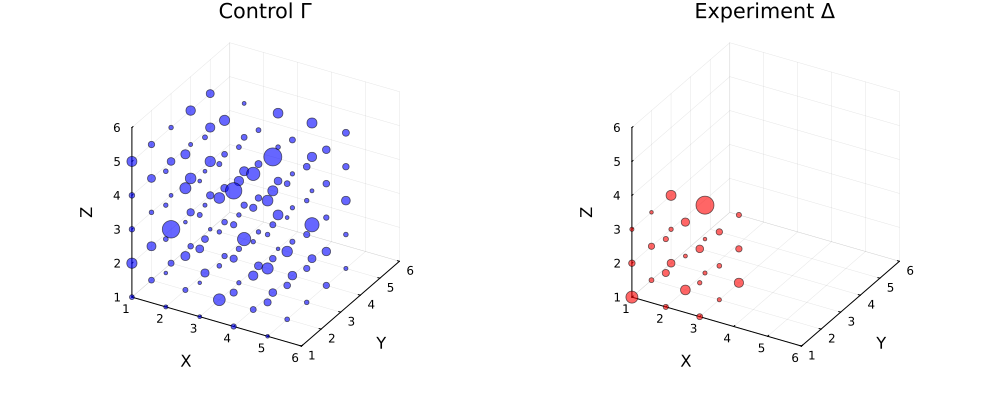

In [3]:
p1 = plot_tensor(Γ; title="Control Γ", color=:blue)
p2 = plot_tensor(Δ; title="Experiment Δ", color=:red)
Plots.plot(p1, p2, layout=(1,2), size=(1000, 400))

The control tensor very likely has few to no all zero axes whereas the experiment evidently does.  The role of chiseling is to recover such anamolies without knowing ahead of time.  So we now randomize the experiment so as to obscure this data.  Note that the randomization applies random bases change so the original coordinates.  

It should now be much less obvious that the control and experminet are any different.

In [4]:
# repeat all the conversions on control, makes sure types stay in sync.
Γ_rand, Xs = randomize_tensor(Γ);
@assert isapprox(Γ * Xs, Γ_rand)

Δ_rand, Ys = randomize_tensor(Δ);  # In theory Δ_rand = Δ*Xs
# Equality check is often too strict, approximate check is better
@assert isapprox(Δ * Ys, Δ_rand)

You may discover `randomize` has switched the internal representation of tensors the `ITensor` format.  In fact this why we are able to apply a **list** (Julia `Vector` types) of matrices to `Δ` without specifying what side to multiply on.  The order is immaterial, for example `Xs*Δ` is allowable as well.  This is in contrast to matrix multiplication where sides indicate the axis of application.  `ITensors` uses internal markers to permit the correct application across multiple axes.

To see the contents in its original array format you can use `asarray(Δ)`.

In [5]:
side_by_side(Γ_rand, Δ_rand;
            left_title="Control Γ", right_title="Experiment Δ_rand")

Control Γ 
 5×5×5 Array{Float64, 3}:
[:, :, 1] =
 -0.283721 -12.2479 22.428 16.8479 -7.86639
 14.4073 -5.95858 -18.7734 -4.75522 -2.17432
 15.486 3.06725 2.58519 6.53064 3.55852
 8.18309 -17.9011 26.2726 23.4122 -10.5695
 16.6521 -7.83732 0.707948 7.59145 -3.07403

[:, :, 2] =
 -17.3307 -0.454389 20.1318 23.0987 -10.6752
 34.9666 -16.2624 -8.29305 9.94768 -5.35424
 6.04013 -3.10908 -22.744 -32.988 14.0607
 -2.84633 -4.65834 27.7452 31.3125 -11.8768
 18.5675 -12.3181 -9.13876 -1.84473 -1.17765

[:, :, 3] =
 -12.9787 5.77791 2.37682 10.7568 -4.35043
 24.9462 -4.87231 12.5982 14.9126 0.998219
 12.018 -4.87127 -14.3743 -18.8566 7.46438
 -13.7317 6.02963 -1.5714 1.77522 -2.20893
 15.5932 -2.19197 -5.72316 0.470162 1.37039

[:, :, 4] =
 1.59109 6.83211 2.30157 5.98238 1.57784
 12.0445 -9.47852 4.10693 11.6003 -5.38383
 -11.7255 -5.22025 -10.3346 -19.8158 4.20883
 -1.774 11.739 -0.0406862 2.21766 2.69781
 1.31764 -0.642987 -1.85921 -3.53213 2.56397

[:, :, 5] =
 5.33454 9.51342 -3.95157 -4.41569 6.4265
 0.453958 -7.83573 1.19179 9.21861 -7.8008
 -23.2384 -7.38779 -3.78297 -15.3158 0.109318
 0.329778 17.2109 -6.17128 -3.52587 6.20899
 -8.38411 -0.403382 0.550573 -2.09356 -0.026648 
 
 
 Experiment Δ_rand 
 5×5×5 Array{Float64, 3}:
[:, :, 1] =
 19.1352 -17.6837 0.76007 12.3546 11.6174
 1.61813 -1.28278 0.150483 1.05835 1.41802
 0.423262 -0.618974 -0.0709088 0.262177 -0.201819
 -7.61679 7.57378 -0.0447147 -4.853 -3.45823
 -4.91716 3.2864 -0.295416 -2.9496 -4.85844

[:, :, 2] =
 9.22569 -10.1215 6.25595 10.7278 13.5575
 -1.67661 0.70712 1.84734 0.545199 1.12979
 2.69071 -1.79399 -1.22059 0.582481 0.29062
 -11.1362 8.88257 1.29828 -5.55655 -5.67737
 -0.680822 2.57582 -4.68131 -4.37353 -5.77356

[:, :, 3] =
 -20.2735 12.9887 8.4029 -4.85464 -4.26761
 -0.66446 -0.406047 2.13765 1.42753 1.93333
 -1.62686 1.91969 -1.25193 -2.03479 -2.46379
 10.2408 -8.77501 1.04912 6.92665 8.2525
 -5.69981 7.35292 -2.55781 -5.91531 -4.64371

[:, :, 4] =
 4.95213 -3.21564 -1.92975 1.28761 1.19522
 0.125639 0.1154 -0.486573 -0.340546 -0.454797
 0.434153 -0.489376 0.28264 0.499187 0.600134
 -2.61591 2.22592 -0.231906 -1.73873 -2.0671
 1.38717 -1.74777 0.542731 1.3702 1.04959

[:, :, 5] =
 26.3159 -14.4952 -19.1463 -0.404691 -5.41168
 4.1001 -1.17101 -5.23811 -2.00347 -3.24518
 -1.16053 -0.546384 3.26325 2.10384 2.78921
 -3.41533 4.43626 -3.16491 -4.76864 -5.54463
 5.5866 -11.3095 9.49759 11.9875 11.008

Or see it again as a plot.

Plotting 125 points with value-proportional sizes...
Plotting 125 points with value-proportional sizes...


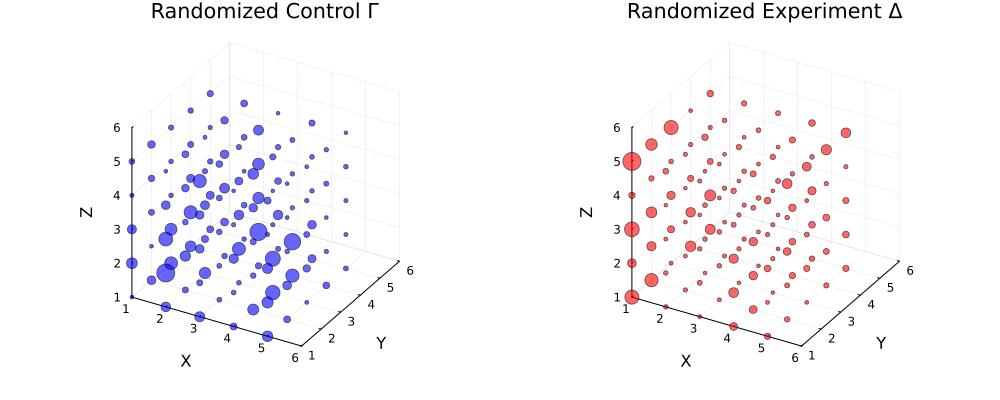

In [6]:
p1 = plot_tensor(Γ_rand; title="Randomized Control Γ", color=:blue)
p2 = plot_tensor(Δ_rand; title="Randomized Experiment Δ", color=:red)
Plots.plot(p1, p2, layout=(1,2), size=(1000, 400))

The goal now is to detect the rows, columns, and slices of 0's, that is the Tucker decomposition, of the experiment.  As warned, there is a more efficient tool than chiseling and just to help our users be aware to use the right tool here it is in practice before we continue with our chiselling experiment anyway.

Plotting 125 points with value-proportional sizes...
Plotting 27 points with value-proportional sizes...


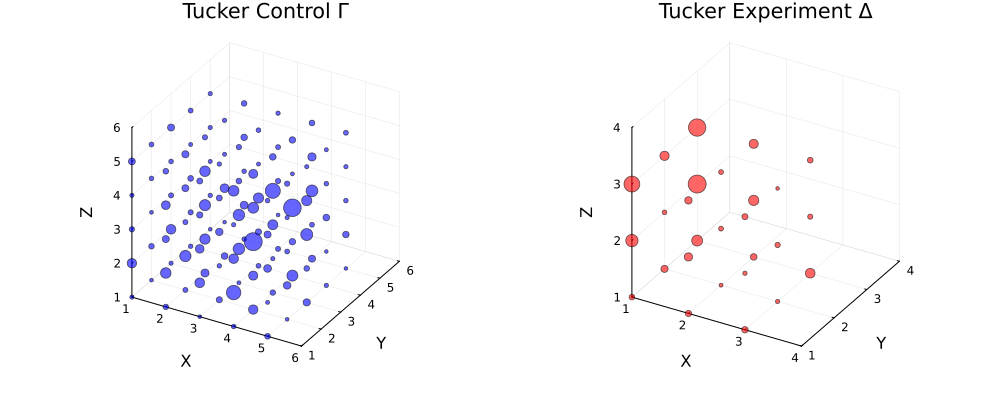

In [ ]:
Γ_nondeg, Xs = Dleto.nondeg(Γ_rand, mode=:full);  # use mode=:trunc to truncate the 0's in the Tucker decomposition
@assert isapprox(Γ_rand * Xs, Γ_nondeg)
Δ_nondeg, Ys = Dleto.nondeg(Δ_rand, mode=:full);
@assert isapprox(Δ_rand * Ys, Δ_nondeg)

p1 = plot_tensor(Γ_nondeg; title="Tucker Control Γ", color=:blue)
p2 = plot_tensor(Δ_nondeg; title="Tucker Experiment Δ", color=:red)
Plots.plot(p1, p2, layout=(1,2), size=(1000, 400))

# 3. Tucker Chiseling

While the command `nondeg` performs the Tucker decomposition on one step, it does so with internal optimizations that mostly do not relate to the chisel strategy more generally.  So to break-down the Tucker decomposition using Tucker Chisels specifically we make a 3 step process.
 * Select the appropriate Tucker chisel
 * Compute derivations of the tensor with the Tucker chisel.
 * Use the derivations to stratify the original tensor.

First let us use the default universal chisel to see what happens.

In [ ]:
Γ_strat, Xs = stratify(Γ_rand);
Δ_strat, Ys = stratify(Δ_rand);

Now let us plot the results of generic stratification.  In a typical situation the control tensor will remain random scatter plot of values spread across all axes.  Meanwhile the stratified experiment will recover a cluster surrounded by nearly zero values.  The precise position of the nonzeros can vary but the total nonzero cluster should be of dimensions `ds-rs`.

In [ ]:
p1 = plot_tensor(Γ_strat; title="Stratified Control Γ", color=:blue)
p2 = plot_tensor(Δ_strat; title="Stratified Experiment Δ", color=:red)
Plots.plot(p1, p2, layout=(1,2), size=(1000, 400))

The plots here are showing dots whose volume is proportional to scalar size, which can omit tiny values.  Inspecting the actual data tells the store in more detail.  In particular we do not manage to up a small tolerance we see that we have recovered the degeneracy planted in the experimental tensor.

In [ ]:
side_by_side(Γ_strat, Δ_strat;
            left_title="Stratified Control Γ", right_title="Stratified Experiment Δ")

# 3. Larger scale

Now let us increase the scale.

In [ ]:
ds = (50,50,50); rs=(40,44,39)
Γ = randn(Float64, ds);  # a control tensor
Γ_rand, Xs = randomize_tensor(Γ);

# the experiment tensor is initially 0 but we fill in a subregion.
Δ = zeros(Float64, ds);  
Δ[1:rs[1], 1:rs[2], 1:rs[3]] .= randn(rs...)
Δ_rand, Ys = randomize_tensor(Δ);  # In theory Δ_rand = Δ*Xs

p1 = plot_tensor(Γ_rand; title="Stratified Control Γ", color=:blue)
p2 = plot_tensor(Δ_rand; title="Stratified Experiment Δ", color=:red)
Plots.plot(p1, p2, layout=(1,2), size=(1000, 400))

As a reference point let us search out the Tucker decomposition in the more efficient manner and plot the results.  Make sure to observe the different range in results.

In [ ]:
Γ_nondeg, Xs = Dleto.nondeg(Γ_rand);
isapprox(Γ_rand * Xs, Γ_nondeg)
Δ_nondeg, Ys = Dleto.nondeg(Δ_rand);
isapprox(Δ_rand * Ys, Δ_nondeg)

p1 = plot_tensor(Γ_nondeg; title="Tucker Control Γ", color=:blue)
p2 = plot_tensor(Δ_nondeg; title="Tucker Experiment Δ", color=:red)
Plots.plot(p1, p2, layout=(1,2), size=(1000, 400))

And if the scales on the graphics are not convincing we can plot the dimensions.

In [ ]:
println("Control tensor nonddeg sizes: ", size(Γ_nondeg))
println("Experiment tensor nonddeg sizes: ", size(Δ_nondeg))

Now lets us begin to chisel.

In [ ]:
Γ_strat, Xs = stratify(Γ_rand);
Δ_strat, Ys = stratify(Δ_rand);


In [ ]:

p1 = plot_tensor(Γ_strat; title="Stratified Control Γ", color=:blue)
p2 = plot_tensor(Δ_strat, 1e-14; title="Stratified Experiment Δ", color=:red)
Plots.plot(p1, p2, layout=(1,2), size=(1000, 400))

In [ ]:
as = Array(Δ_strat,inds(Δ_strat)...);
heatmap(as[:,:,25]', title="Slice of Δ_rand at index 25", color=:reds)
# as[:,25,:]

# 4. 

You see the default setting used only 10 of the available 75 values.  The value $75=3\cdot 5^2$ coincides with being a 3-valent tensor with dimensions `(5,5,5)` so it will take three $5\times 5$-operators to manipulate for a total of 75 parameters.  However there are also $125=5^3$ constraint equations so we should expect few solutions.  Thus as a practical improvement, `Dleto.jl` estimates only 10 solutions will be necessary and accelorate the calculations knowing this heuristic value.

To explain the process in full, let us override this heuristic cut-off and take all the available values.  Note, if we give `chisel` a number greater than the available values or one that is negative, then all values are computed. 

The behavior demonstrated is a response to the number of 0's we included as rows, columns, and slices in the experiment.  It may become more noticeable to plot the derviatives, using `diff(xxx_t.values)`.  

Unfortunately, the steep changes in behavior near the final values can overwhellem the comparisons we are after near the small values, which is what we care to track.  Those carry little useable information as we can see they occur at the same range.  It is for this reason that we typically do not include the larger values.  By replotting the data with smaller range we can better see the differences between control and experiment.

**We are interested in the index location of the first spike in the differences.**

In [ ]:
p1 = plot(diff(ctr_spall.values[1:50]),  xlabel="Index", ylabel="Value", title="Control Spall Values", color=:blue)
p2 = plot(diff(exp_spall.values[1:50]),  xlabel="Index", ylabel="Value", title="Experiment Spall Values", color=:red)
plot(p1, p2, layout=(1,2), size=(1000, 400))

You may notice the number of 0's in the experimental plot increase with the number of all zero rows, columns, and slices. You may even be able to estimate a formula on the order of the following.
```math
2 + d_1\cdot r_1 + d_2 \cdot r_2 + d_3\cdot r_3
```
> While not important to chisel selection, the orgin of this formula can be seen as the number of matrices mapping $\mathbb{R}^{d_i}\to \mathbb{R}^{r_i}$ for each axis $i\in \{1,2,3\}$ plus the initial 2 dimensions that are present for all tensors of valence 2.  Note that these numbers are also specific to the universal chisel which we get by default when using `chisel(xxx_t)`.

## Recovering blocks from the chiseling spall


In [ ]:
sculpted_ctr = sculpt(ctr_t, ctr_spall, collect(3:3));
sculpted_exp = sculpt(exp_t, exp_spall, collect(3:3));
sidebyside(round.(100*sculpted_ctr.tensor), round.(100*sculpted_exp.tensor); 
left_title="Control Sculpted Vec", right_title="Experiment Sculpted Vec")